# PPG Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the PPG dataset.

**Objectives:**
- Compare S4 vs LMU performance
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful")

## 4. Load PPG Experiment Results

Load all S4 and LMU results across different data fractions.


In [3]:
from src.eval.compare import load_all_experiments

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "ppg"

print("="*60)
print("LOADING PPG EXPERIMENT RESULTS")
print("="*60)
print()

# Load all results
all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")


LOADING PPG EXPERIMENT RESULTS

📂 Loading S4 @ 10%: ppg_s4_task_frac_10
📂 Loading S4 @ 25%: ppg_s4_task_frac_25
📂 Loading S4 @ 50%: ppg_s4_task_frac_50
📂 Loading S4 @ 100%: ppg_s4_task
📂 Loading LMU @ 10%: ppg_lmu_task_frac_10
📂 Loading LMU @ 25%: ppg_lmu_task_frac_25
📂 Loading LMU @ 50%: ppg_lmu_task_frac_50
📂 Loading LMU @ 100%: ppg_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## 5. Comparison Table

Summary table of all experiments and their metrics.


In [4]:
from src.eval.compare import create_comparison_table

print("="*60)
print("EXPERIMENT COMPARISON TABLE")
print("="*60)
print()

comparison_df = create_comparison_table(
    all_results,
    metrics=['best_val_mae', 'best_val_loss', 'final_val_mae', 'epochs_trained']
)

print(comparison_df.to_string(index=False))
print()

# Save to CSV
csv_path = Path("./comparison_results.csv")
comparison_df.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")


EXPERIMENT COMPARISON TABLE

Model Data %  Fraction best_val_mae best_val_loss final_val_mae  epochs_trained
   S4    10%      0.10      11.0931      216.9953       11.0931              16
   S4    25%      0.25      12.8696      272.5885       12.8696               7
   S4    50%      0.50       8.5853      145.4263        8.5853              20
   S4   100%      1.00       7.4365      119.1143        7.4365              21
  LMU    10%      0.10      10.8018      228.7497       10.8018              35
  LMU    25%      0.25       9.5063      191.3651        9.5063              29
  LMU    50%      0.50       9.3759      172.1609        9.3759              10
  LMU   100%      1.00       8.6682      148.4415        8.6682              11

Saved to: comparison_results.csv


## 6. Validation Loss Learning Curves

Compare how validation loss evolves during training for different data fractions.


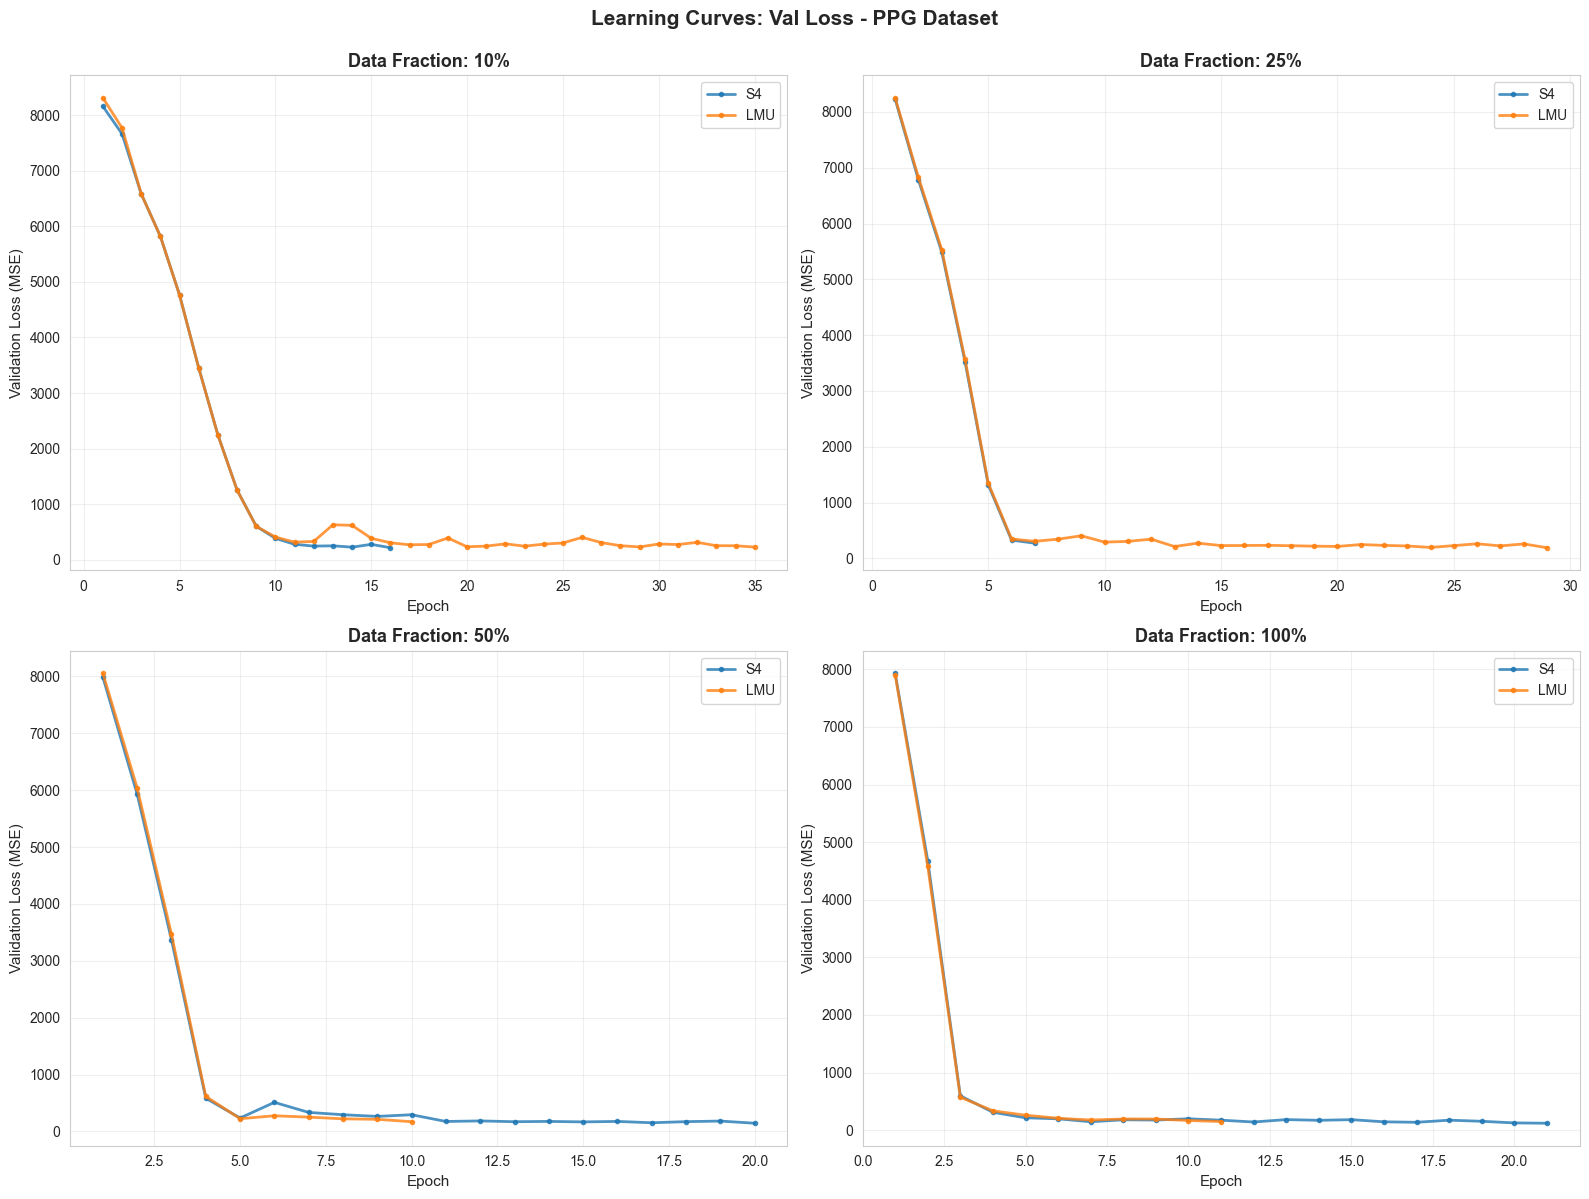

In [5]:
from src.eval.compare import plot_learning_curves

plot_learning_curves(
    all_results,
    metric='val_loss',
    title_suffix=' - PPG Dataset',
    ylabel='Validation Loss (MSE)'
)


## 7. Validation MAE Learning Curves

Compare MAE (Mean Absolute Error) across training.


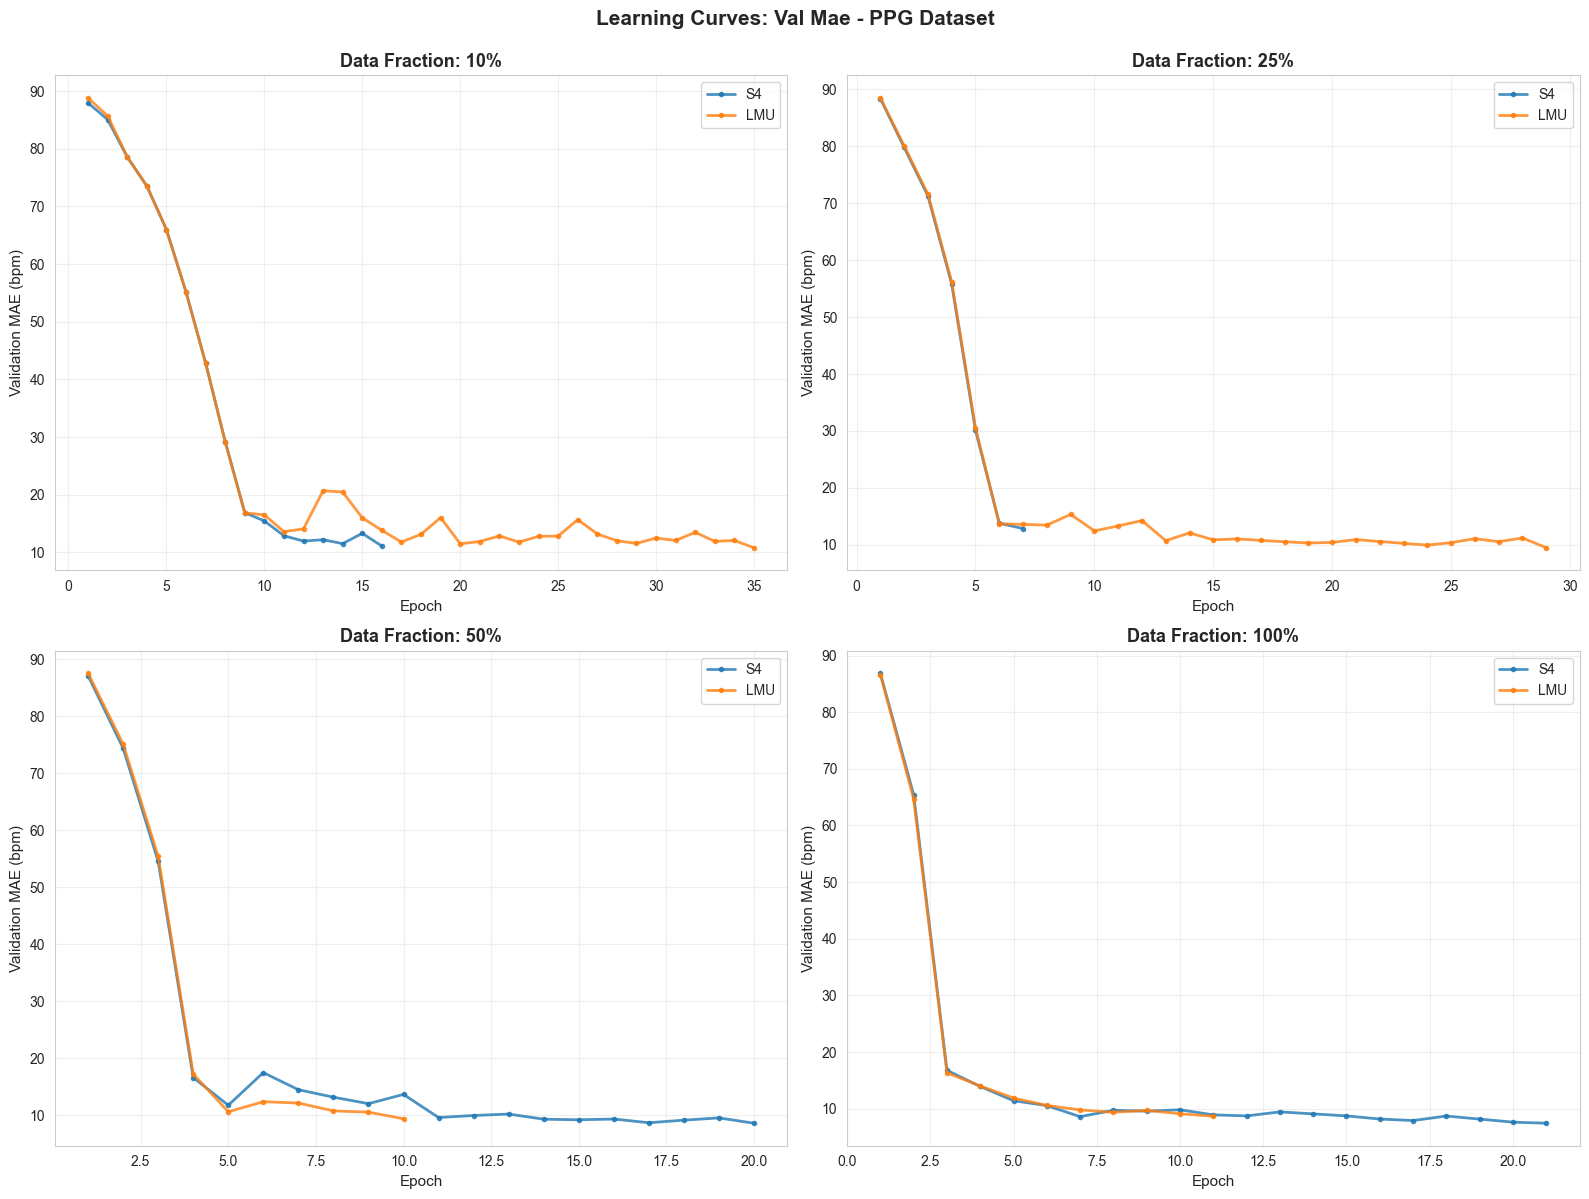

In [6]:
plot_learning_curves(
    all_results,
    metric='val_mae',
    title_suffix=' - PPG Dataset',
    ylabel='Validation MAE (bpm)'
)


## 8. Best Performance Comparison

Bar chart showing best validation MAE for each model and fraction.


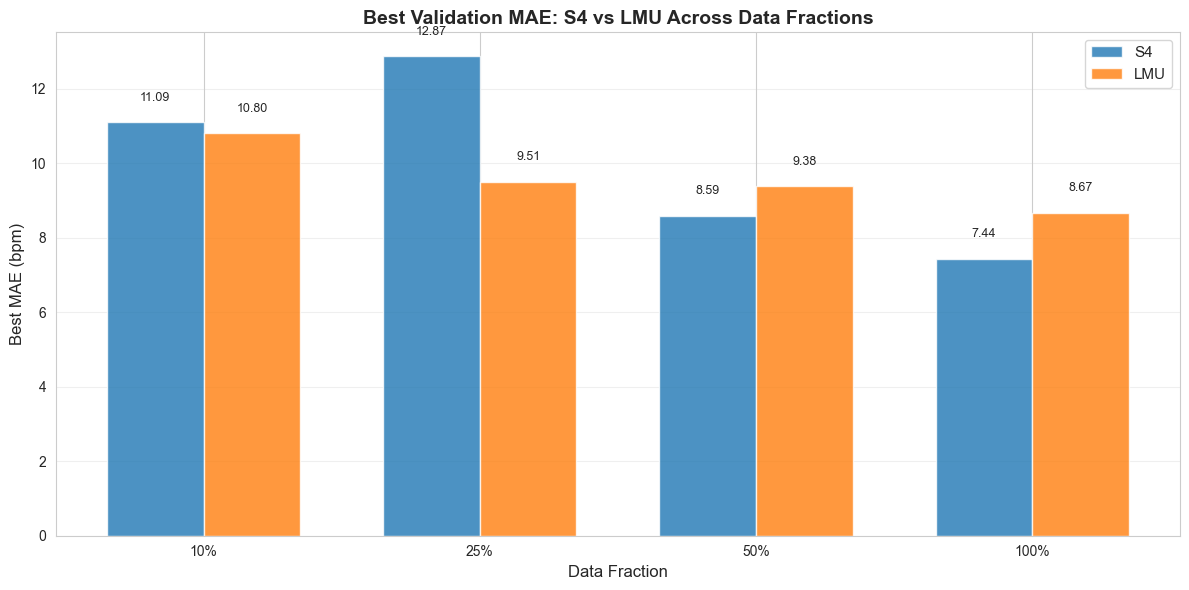

In [7]:
from src.eval.compare import plot_metric_comparison_bar

plot_metric_comparison_bar(
    all_results,
    metric_key='best_val_mae',
    title='Best Validation MAE: S4 vs LMU Across Data Fractions',
    ylabel='Best MAE (bpm)',
    lower_is_better=True
)


## 9. Data Efficiency Analysis

Which model learns better with limited data?


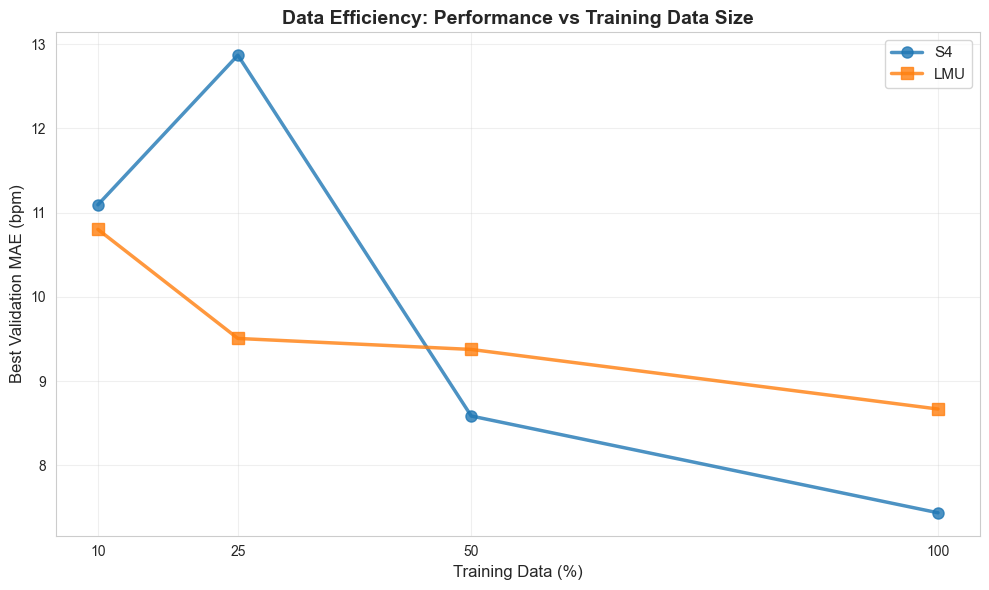

In [8]:
from src.eval.compare import plot_data_efficiency

plot_data_efficiency(
    all_results,
    metric_key='best_val_mae',
    ylabel='Best Validation MAE (bpm)'
)

## 10. Detailed Analysis

Calculate retention rates and data efficiency metrics.


In [9]:
print("="*60)
print("DATA EFFICIENCY ANALYSIS")
print("="*60)
print()

for model in models:
    print(f"\n{model.upper()} Model:")
    print("-" * 40)

    # Get full data performance as baseline
    full_results = all_results[model].get(1.0, {})
    if not full_results or 'best_val_mae' not in full_results:
        print("No full data results available")
        continue

    full_mae = full_results['best_val_mae']
    print(f"  Full data (100%): MAE = {full_mae:.2f} bpm")
    print()

    # Compare fractional data
    for frac in [0.1, 0.25, 0.5]:
        frac_results = all_results[model].get(frac, {})
        if not frac_results or 'best_val_mae' not in frac_results:
            continue

        frac_mae = frac_results['best_val_mae']
        retention = (full_mae / frac_mae) * 100 if frac_mae > 0 else 0
        degradation = ((frac_mae - full_mae) / full_mae) * 100

        print(f"  {int(frac*100)}% data:")
        print(f"    MAE = {frac_mae:.2f} bpm")
        print(f"    Degradation: +{degradation:.1f}%")
        print(f"    Quality retention: {100-degradation:.1f}%")
        print()


DATA EFFICIENCY ANALYSIS


S4 Model:
----------------------------------------
  Full data (100%): MAE = 7.44 bpm

  10% data:
    MAE = 11.09 bpm
    Degradation: +49.2%
    Quality retention: 50.8%

  25% data:
    MAE = 12.87 bpm
    Degradation: +73.1%
    Quality retention: 26.9%

  50% data:
    MAE = 8.59 bpm
    Degradation: +15.4%
    Quality retention: 84.6%


LMU Model:
----------------------------------------
  Full data (100%): MAE = 8.67 bpm

  10% data:
    MAE = 10.80 bpm
    Degradation: +24.6%
    Quality retention: 75.4%

  25% data:
    MAE = 9.51 bpm
    Degradation: +9.7%
    Quality retention: 90.3%

  50% data:
    MAE = 9.38 bpm
    Degradation: +8.2%
    Quality retention: 91.8%



## 11. Winner Analysis

Which model performs best at each data fraction?


In [10]:
print("="*60)
print("WINNER ANALYSIS")
print("="*60)
print()

for frac in fractions:
    print(f"\n📊 Data Fraction: {int(frac*100)}%")
    print("-" * 40)

    best_model = None
    best_mae = float('inf')

    for model in models:
        results = all_results[model].get(frac, {})
        if results and 'best_val_mae' in results:
            mae = results['best_val_mae']
            print(f"  {model.upper():3s}: {mae:.2f} bpm")

            if mae < best_mae:
                best_mae = mae
                best_model = model

    if best_model:
        print(f"\n  🏆 Winner: {best_model.upper()} (MAE: {best_mae:.2f} bpm)")

        # Calculate margin
        for model in models:
            if model != best_model:
                other_results = all_results[model].get(frac, {})
                if other_results and 'best_val_mae' in other_results:
                    other_mae = other_results['best_val_mae']
                    improvement = ((other_mae - best_mae) / other_mae) * 100
                    print(f"  Beats {model.upper()} by {improvement:.1f}%")


WINNER ANALYSIS


📊 Data Fraction: 10%
----------------------------------------
  S4 : 11.09 bpm
  LMU: 10.80 bpm

  🏆 Winner: LMU (MAE: 10.80 bpm)
  Beats S4 by 2.6%

📊 Data Fraction: 25%
----------------------------------------
  S4 : 12.87 bpm
  LMU: 9.51 bpm

  🏆 Winner: LMU (MAE: 9.51 bpm)
  Beats S4 by 26.1%

📊 Data Fraction: 50%
----------------------------------------
  S4 : 8.59 bpm
  LMU: 9.38 bpm

  🏆 Winner: S4 (MAE: 8.59 bpm)
  Beats LMU by 8.4%

📊 Data Fraction: 100%
----------------------------------------
  S4 : 7.44 bpm
  LMU: 8.67 bpm

  🏆 Winner: S4 (MAE: 7.44 bpm)
  Beats LMU by 14.2%
